# **2D Hamiltonian: allowed energy levels and wavefunctions**

&emsp;This notebook seeks to explore the eigenvectors (and corresponding eigenvalues) associated with the Hamiltonian in two spatial dimensions. The procedurer will resemble that of the 1D case, making use of finite differences.Dimensionless units will continue to be utilized throughout this exercise; i.e., 
$$\hbar = m = \omega = 1$$
&emsp;Therefore, the 2D Hamiltonian is:
$$H = -\frac{1}{2}(\frac{\partial^2}{{\partial x}^2}+\frac{\partial^2}{{\partial y}^2})+\frac{1}{2}(x^2+y^2)$$


&emsp;In this case, the analytic energies are given by 
$$E_{n_x,n_y}= n_x + n_y +1$$
for $n_x, n_y = 0,1,2,3,...$

In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import diags, kronsum
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal
from scipy.linalg import eigh
import matplotlib.pyplot as plt

## **Preparation** 

The conditions for this instance will remain (almost) intact with respect to the one-dimensional case:
- Physical units: dimensionless, $\hbar =m = \omega = 1$
- Spatial interval: $x,y \in [-L,L]$ with $L=8$
- Number of grid points: *$N=100$*, including the two boundary points
    - Number of grid points must be reduced to decrease memory demand as matrix dimensions grow as $N^2$
- Dirichlet boundary condition: $\psi(\pm L)=0$
- Requested eigenestates: lowest six


In [205]:
hbar = 1.0
mass = 1.0
omega = 1.0

# WARNING: Keep N smaller 
N_2d = 100
L = 8.0

num_states = 6

x_2d = np.linspace(-L, L, N_2d)
y_2d = np.linspace(-L, L, N_2d)

dx = x_2d[1] - x_2d[0]
dy = y_2d[1] - y_2d[0]

x = x_2d[1:-1]
y = y_2d[1:-1]

M = x.size



## **The finite-difference**

&emsp;In 2D, the second derivative is expressed by the Laplacian operator $\nabla^2$, which is the sum of the second derivative in the x-direction and second derivative in the y-direction. Let the 2D grid have points denoted by the index pair $(i,j)$ for the x and y coordinates respectively. The second-order finite difference approximation is then:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}-2{\psi}_{i,j}+{\psi}_{i-1,j}}{\Delta x^2}+\frac{{\psi}_{i,j+1}-2{\psi}_{i,j}+{\psi}_{i,j-1}}{\Delta y^2}$$

&emsp;Since $\Delta x = \Delta y$, we may simplify the expression and produce the following:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}+{\psi}_{i-1,j}+{\psi}_{i,j+1}+{\psi}_{i,j-1}-4{\psi}_{i,j}}{\Delta x^2}$$

&emsp;Appliying this procedure produces a matrix that is not necessarily tridiagonal in the traditional sense. Given that we must flatten the M matrix into a vector (of length $M^2$) to produce the Hamiltonian matrix. When calculating the laplacian for a particular point, we take the points around it (above, below, left, and right). To get to the point directly above or below in the matrix, M spaces in the vector must be traversed. This process of translation between spaces places ones along the off-diagonals that are located M rows below the original diagonal in the Hamiltonian matrix; it also gives ones along the immediate off-diagonals. This behavior is captured and expressed by the `scipy.sparse.kronsum` instance.  

&emsp;As before (almost), a demonstration with a minute two-by-two grid shall be performed before applying the technique to a larger grid.

In [206]:
M_demo = 3

main = -2.0 * np.ones(M_demo)
lower = np.ones(M_demo - 1)
upper = np.ones(M_demo - 1)
D2_x = diags([lower, main, upper], [-1, 0, 1], shape=(M_demo,M_demo), format="csr") / dx**2
D2_y = diags([lower, main, upper], [-1, 0, 1], shape=(M_demo,M_demo), format="csr") / dy**2

D2_2D_demo = kronsum(D2_y, D2_x, format="csr")
print(D2_2D_demo.toarray())



[[-153.140625     38.28515625    0.           38.28515625    0.
     0.            0.            0.            0.        ]
 [  38.28515625 -153.140625     38.28515625    0.           38.28515625
     0.            0.            0.            0.        ]
 [   0.           38.28515625 -153.140625      0.            0.
    38.28515625    0.            0.            0.        ]
 [  38.28515625    0.            0.         -153.140625     38.28515625
     0.           38.28515625    0.            0.        ]
 [   0.           38.28515625    0.           38.28515625 -153.140625
    38.28515625    0.           38.28515625    0.        ]
 [   0.            0.           38.28515625    0.           38.28515625
  -153.140625      0.            0.           38.28515625]
 [   0.            0.            0.           38.28515625    0.
     0.         -153.140625     38.28515625    0.        ]
 [   0.            0.            0.            0.           38.28515625
     0.           38.28515625 -153.14

To visualize the array, a heatmap is employed.

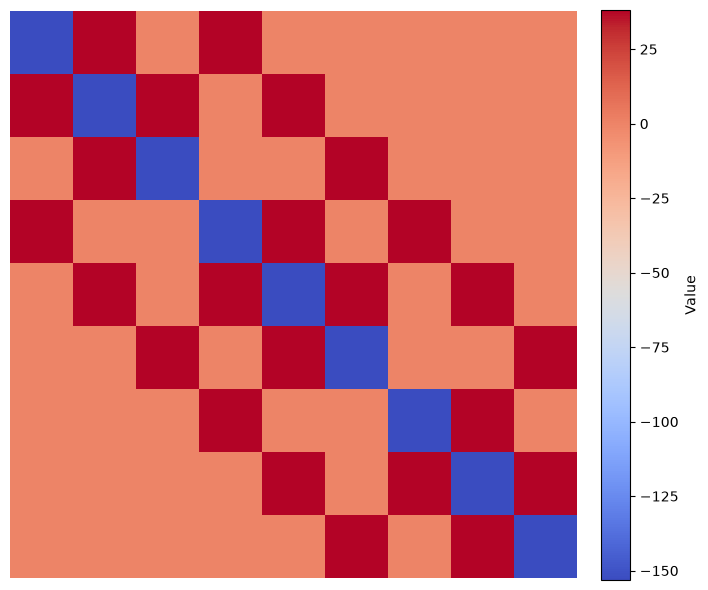

In [207]:
plt.figure(figsize=(8, 8))

d_matrix = D2_2D_demo.toarray() if hasattr(D2_2D_demo, 'toarray') else D2_2D_demo
plt.imshow(d_matrix, cmap='coolwarm', interpolation='nearest')
plt.axis('off') 
plt.grid(False)
plt.colorbar(label="Value", fraction=0.046, pad=0.04)
plt.show()

&emsp;The produced array is already scaled.
Notice the difference with respect to the array generated for the 1D case. The immediate off-diagonals are not lines of uninterrupted non-zero entries, and there are additional diagonal lines with all non-zero entries. 
We may proceed to create a bigger array (with $N=20$).

In [208]:
main = -2.0 * np.ones(M)
lower = np.ones(M - 1)
upper = np.ones(M - 1)
D2_x = diags([lower, main, upper], [-1, 0, 1], shape=(M,M), format="csr") / dx**2
D2_y = diags([lower, main, upper], [-1, 0, 1], shape=(M,M), format="csr") / dy**2

D2_2D = kronsum(D2_y, D2_x, format="csr")



Creating the potential grid.

In [209]:
X, Y = np.meshgrid(x,y)
V_2D = 0.5 * mass * omega**2 * (X**2 + Y**2)
V_diag = diags(V_2D.flatten(), offsets=0, format="csr")


## **The Hamiltonian Matrix**

&emsp;With the potential grid constructed, we can form the Hamiltonian Matrix by adding the potential matrix to the D matrix.

In [210]:
H_2D = -0.5 * (hbar**2 / mass) * D2_2D + V_diag

Obtaining the allowed energy levels. In this, we will use `scipy.sparse.linalg.eigsh` with the same `k=num_states` and `which="SA"` arguments. The reasons for these selections have been detailed in the 1D case. 

In [211]:
energies_2d, states_2d = eigsh(H_2D, k=num_states, which="SA")

order = np.argsort(energies_2d)
energies_2d = energies_2d[order]
states_2d = states_2d[:, order]
for j in range(num_states):             #normalizing the wavefunctions
    psi_2d = states_2d[:, j].reshape((M, M))
    
    int_x = np.trapezoid(np.abs(psi_2d)**2, dx=dx, axis=1)
    int_2d = np.trapezoid(int_x, dx=dy)
    
    states_2d[:, j] /= np.sqrt(int_2d)
for j in range(num_states):
    print(f"E_{j} = {energies_2d[j]:.10f}")

E_0 = 0.9983648354
E_1 = 1.9950891099
E_2 = 1.9950891099
E_3 = 2.9885240673
E_4 = 2.9885240673
E_5 = 2.9918133844


Here is the evaluation of the difference between the two solvers. The secondary method used is `scipy.linalg.eigh`.

In [212]:
H = H_2D.toarray()
energies_ref, states_ref = eigh(H, subset_by_index=[0, num_states - 1])
solver_difference = np.abs(energies_2d - energies_ref).max()
print(f"Largest eigsh vs eigh difference: {solver_difference:.3e}")
assert solver_difference < 1e-9, "the two solvers disagree"
overlap = states_2d.T @ states_2d * dx
print(f"Maximum normalization error: {np.max(np.abs(np.diag(overlap) - 1.0)):.3e}")
print(f"Maximum orthogonality error: {np.max(np.abs(overlap - np.eye(num_states))):.3e}")

Largest eigsh vs eigh difference: 5.440e-14
Maximum normalization error: 5.187e+00
Maximum orthogonality error: 5.187e+00


## **Visualizing the discrepancies**

&emsp; In this case, the energies are given by 
$$E_{n_x,n_y}=n_x + n_y + 1, \qquad n=0,1,2,3,...$$
with the table below giving the numerical and analytical values, as well as the absolute ($|E_n^{num}-E_n|$) and relative differences (as a percentage). 

In [213]:

n = np.arange(num_states)
nx, ny = np.meshgrid(n,n)
energies = nx +ny + 1.0
energies_exact = np.sort(energies.flatten())[:num_states]
absolute_difference = np.abs(energies_2d - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_2d,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})
comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.998365,1.0,0.001635,0.163516
1,1,1.995089,2.0,0.004911,0.245545
2,2,1.995089,2.0,0.004911,0.245545
3,3,2.988524,3.0,0.011476,0.382531
4,4,2.988524,3.0,0.011476,0.382531
5,5,2.991813,3.0,0.008187,0.272887


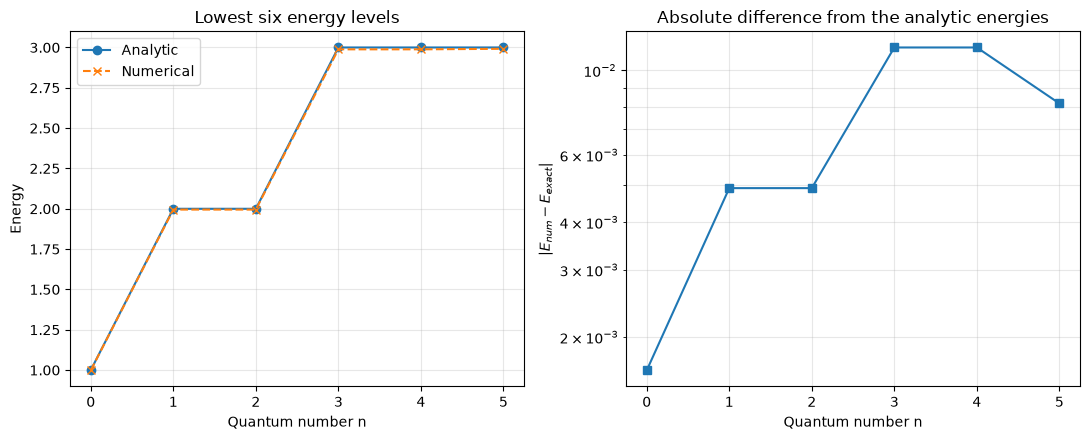

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n, energies_exact, "o-", label="Analytic")
axes[0].plot(n, energies_2d, "x--", label="Numerical")
axes[0].set_xlabel("Quantum number n")
axes[0].set_ylabel("Energy")
axes[0].set_title("Lowest six energy levels")
axes[0].set_xticks(n)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(n, absolute_difference, "s-")
axes[1].set_xlabel("Quantum number n")
axes[1].set_ylabel(r"$|E_{num} - E_{exact}|$")
axes[1].set_title("Absolute difference from the analytic energies")
axes[1].set_xticks(n)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## **Result**

&emsp;For the 2d case, the six lowest numerical energy levels produce approximations with an error of at most $11.5\times10^{-3}$ with respect to the exact energy levels $E_n = n_x +n_y+1$. The relative maximum difference is about 0.38%. The two methods produce results that agree with each other to approximately $5.4\times10^{-14}$. As observed in the 1D case:
- The numerical values are lower than the analytical values due to the underestimation of the curvature of the wavefunction (and consequently the kinetic energy).
- The discrepancy (in general) increases with n as the oscillations become faster and wider, making the finite size of the box more noticeable. 

&emsp; Both of these effects - as discussed for the 1D case, should decrease as the grid spacing is decreased by the square of the grid spacing. Additionally, the box size $L$ also contributes to the mitigation of the discrepancies.